In [ ]:
!date

Mon Sep  7 20:24:42 PDT 2026


In [ ]:
import glob, subprocess, tempfile
from itertools import combinations

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

projdir = '/u/project/cluo/terencew/claude/project_ideas/asm_lr'

In [ ]:
### load significant regions, all 6 confirmed-sane donors, all 22 chroms
donors = ['NA19700','HG02392','HG00146','NA19682','NA21110','NA18959']
frames = []
for s in donors:
    for f in sorted(glob.glob(f'{projdir}/tables/dasm_betabinom/{s}/regions_chr*.tsv')):
        df = pd.read_csv(f, sep='\t')
        df = df[df.significant == True].copy()
        df['donor'] = s
        frames.append(df)
sig = pd.concat(frames, ignore_index=True)
sig['abs_delta'] = sig['delta'].abs()
sig.head()

  chrom   start     end  n_cpgs  ...          qval  significant    donor  abs_delta
0  chr1  903492  904490      77  ...  2.117531e-05         True  NA19700   0.176889
1  chr1  933650  934314      27  ...  1.315428e-07         True  NA19700   0.294725
2  chr1  934856  935848      92  ...  1.400483e-13         True  NA19700   0.273730
3  chr1  942979  943952      56  ...  2.948213e-02         True  NA19700   0.145085
4  chr1  993343  994216      42  ...  2.123028e-02         True  NA19700   0.118811

[5 rows x 16 columns]

In [ ]:
sig.shape

(41461, 16)

In [ ]:
### merge overlapping significant calls across donors (250bp slop). A single
### donor can contribute >1 nearby region to the same merged interval (2,004
### of 29,891 raw merges do this) -- collapse to one value per donor (max
### |delta|) per locus before counting donors or comparing effect sizes,
### otherwise "n_donors" and the concordance below both get contaminated by
### a donor trivially agreeing with itself.
bed_in = sig[['chrom','start','end','donor','abs_delta']].sort_values(['chrom','start'])
with tempfile.NamedTemporaryFile(mode='w', suffix='.bed', delete=False) as f:
    bed_in.to_csv(f, sep='\t', header=False, index=False)
    bed_path = f.name
cmd = f"sort -k1,1 -k2,2n {bed_path} | /u/home/t/terencew/bin/bedtools merge -d 250 -c 4,5 -o collapse,collapse -i -"
out = subprocess.run(cmd, shell=True, capture_output=True, text=True, check=True)
rows = []
for line in out.stdout.strip().split('\n'):
    chrom, start, end, donors_s, deltas_s = line.split('\t')
    dl = donors_s.split(',')
    dv = [float(x) for x in deltas_s.split(',')]
    per_donor = {}
    for d, v in zip(dl, dv):
        per_donor[d] = max(per_donor.get(d, 0.0), v)
    rows.append((chrom, start, end, len(per_donor), per_donor))
merged = pd.DataFrame(rows, columns=['chrom','start','end','n_donors','donor_delta'])
merged.shape

(29891, 5)

In [ ]:
### how many loci are supported by >=2 (deduplicated) donors, and what does
### effect size look like within a locus across its supporting donors?
multi = merged[merged.n_donors >= 2].copy()
multi['deltas'] = multi['donor_delta'].apply(lambda d: list(d.values()))
multi['delta_mean'] = multi['deltas'].apply(np.mean)
multi['delta_sd'] = multi['deltas'].apply(lambda x: np.std(x, ddof=1) if len(x) > 1 else np.nan)
multi['delta_cv'] = multi['delta_sd'] / multi['delta_mean']
print('n loci, >=2 donors:', len(multi))
print('n loci, >=3 donors:', (multi.n_donors >= 3).sum())
print()
print('within-locus (across supporting donors) mean SD of |delta|:', round(multi['delta_sd'].mean(), 4))
print('within-locus mean |delta|:                                  ', round(multi['delta_mean'].mean(), 4))
print('mean within-locus CV (sd/mean):                             ', round(multi['delta_cv'].mean(), 4))
print('between-locus SD of the per-locus mean |delta|:             ', round(multi['delta_mean'].std(), 4))

n loci, >=2 donors: 4466
n loci, >=3 donors: 1414

within-locus (across supporting donors) mean SD of |delta|: 0.0635
within-locus mean |delta|:                                   0.3039
mean within-locus CV (sd/mean):                              0.2062
between-locus SD of the per-locus mean |delta|:              0.1297


In [ ]:
### variance decomposition: does "which locus" or "which donor observed it"
### explain more of the spread in |delta|?
exploded = multi[['chrom','start','end','deltas']].copy()
exploded['locus_id'] = exploded['chrom'] + ':' + exploded['start'].astype(str) + '-' + exploded['end'].astype(str)
long = exploded.explode('deltas')
long['deltas'] = long['deltas'].astype(float)
grand_mean = long['deltas'].mean()
ss_between = long.groupby('locus_id')['deltas'].apply(lambda x: len(x) * (x.mean() - grand_mean)**2).sum()
ss_within = long.groupby('locus_id')['deltas'].apply(lambda x: ((x - x.mean())**2).sum()).sum()
ss_total = ss_between + ss_within
print(f'n donor-locus observations: {len(long)}, n loci: {multi.shape[0]}')
print(f'fraction of |delta| variance BETWEEN loci (locus identity):  {ss_between/ss_total:.3f}')
print(f'fraction of |delta| variance WITHIN locus (across donors):   {ss_within/ss_total:.3f}')

n donor-locus observations: 11179, n loci: 4466
fraction of |delta| variance BETWEEN loci (locus identity):  0.796
fraction of |delta| variance WITHIN locus (across donors):   0.204


In [ ]:
### pairwise concordance: for every PAIR OF DISTINCT donors that both call
### the same locus, does donor A's |delta| predict donor B's |delta|?
pairs_a, pairs_b = [], []
for row in merged['donor_delta']:
    if len(row) < 2:
        continue
    for d1, d2 in combinations(sorted(row.keys()), 2):
        pairs_a.append(row[d1]); pairs_b.append(row[d2])
pairs_a = np.array(pairs_a); pairs_b = np.array(pairs_b)
r, p = pearsonr(pairs_a, pairs_b)
print(f'n distinct-donor-pair observations at shared loci: {len(pairs_a)}')
print(f'pearson r (|delta| donor A vs donor B, same locus): {r:.3f} (p={p:.2e})')

n distinct-donor-pair observations at shared loci: 10133
pearson r (|delta| donor A vs donor B, same locus): 0.724 (p=0.00e+00)


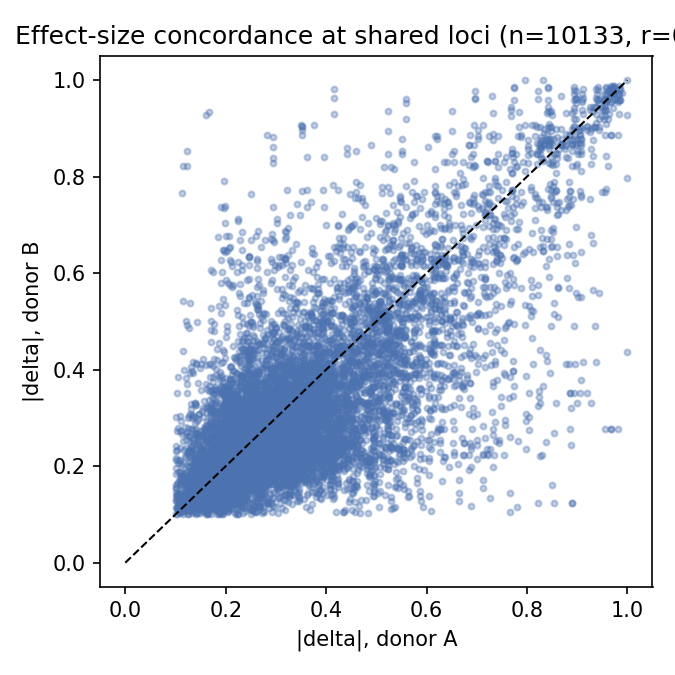

In [ ]:
fig, ax = plt.subplots(figsize=(4.5,4.5))
ax.scatter(pairs_a, pairs_b, s=8, alpha=0.35, color='#4C72B0')
lims = [0, max(pairs_a.max(), pairs_b.max())]
ax.plot(lims, lims, 'k--', lw=1)
ax.set_xlabel('|delta|, donor A')
ax.set_ylabel('|delta|, donor B')
ax.set_title(f'Effect-size concordance at shared loci (n={len(pairs_a)}, r={r:.2f})')
plt.tight_layout()
plt.savefig(f'{projdir}/tables/phasing_qc/fig_effect_size_concordance.png', dpi=150)
plt.show()

In [ ]:
### save the per-locus consistency table
multi.drop(columns=['donor_delta','deltas']).to_csv(
    f'{projdir}/tables/asm_analysis/multi_donor_effect_size_consistency.tsv', sep='\t', index=False)
print('wrote tables/asm_analysis/multi_donor_effect_size_consistency.tsv')

wrote tables/asm_analysis/multi_donor_effect_size_consistency.tsv


In [ ]:
!date

Mon Sep  7 20:25:09 PDT 2026
